# Setup — emission model standardization

Auxiliary notebook, run **once** (or whenever the model files change), *before*
`sim_3d`. It implements Steps 1, 2 and 5 of the simulation guidelines
("Simulation guidelines: from a numerical GRB model to a GW-marginalised IACT
upper limit") and leaves a small, standardized cache on disk that `sim_3d`
loads with a single call — it never has to parse a FITS file, know which of
the three model options was used, or handle multiple viewing angles itself.

| Guidelines step | What happens here |
| --- | --- |
| Step 1 — select the emission model | Read every INAF `catO5_*.fits` angle file (Option 1); also build the analytic (Option 2) and constant-power-law (Option 3) cases |
| Step 2 — rest-frame `L(E', t')` | Exact regrid `E'=(1+z^m)E`, `t'=t/(1+z^m)`, `L = 4π (d_L^m)²/(1+z^m)² · F` |
| Step 5 — the model at any θ | Every angle rescaled to one common `E_iso`, then nearest angle (A) / stochastic nearest (B) / peak-aligned log-L interpolation in θ (C) |
| Validation checklist | Round-trip (Step 2 ∘ Step 7 = identity), EBL spot-checks, single-peak interpolation |

The library code lives in [`gwuls/grb_model.py`](../gwuls/grb_model.py) — this
notebook only calls it and inspects the results. The physics, equations and
checks are written up in [`docs/setup_model.md`](../docs/setup_model.md). The
standardized cache is written to `data/models/grb_afterglow_inaf/standardized/`,
one `.npz` per angle; `sim_3d` (and anything else) loads it back with
`gwuls.grb_model.GRBModelSet.load(paths.GRB_MODEL_STANDARDIZED_DIR)`.


In [1]:
import sys
sys.path.insert(0, "..")

import warnings
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u

from gwuls import grb_model, paths
from importlib import reload
reload(grb_model)

paths.ensure_dirs()


/home/jjimenezq/anaconda3/lib/python3.13/site-packages/igwn_ligolw/lsctables.py:57: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


## Part 1 — Option 1: the INAF / CTA-GW catalogue files

The raw files (`catO5_*.fits`, B. Patricelli's O5 BNS afterglow catalogue —
tabulated `F(E, t)` at one `(d_L^m, z^m, θ^m)` each, no EBL) live in
[`data/models/grb_afterglow_inaf/raw/`](../data/models/grb_afterglow_inaf/raw).
They were copied in from the reference `gwiact` catalogue set; drop in any
further `catO5_*.fits` file here and it is picked up automatically.

In [2]:
cosmology = None  # None -> Planck18 (gwuls.simulate.redshift_from_luminosity_distance default)

raw_files = sorted(paths.GRB_MODEL_RAW_DIR.glob("*.fits"))
print(f"{len(raw_files)} raw model file(s) in {paths.GRB_MODEL_RAW_DIR}:")
for f in raw_files:
    print(" ", f.name)


5 raw model file(s) in /home/jjimenezq/projects/gw-gamma-global-uls/data/models/grb_afterglow_inaf/raw:
  catO5_1378.fits
  catO5_2094.fits
  catO5_26.fits
  catO5_301.fits
  catO5_4.fits


In [3]:
# --- Step 1 (read) + Step 2 (exact regrid to rest frame), for every angle file at once ---
model_set = grb_model.GRBModelSet.from_inaf_dir(paths.GRB_MODEL_RAW_DIR, cosmology=cosmology)

print(f"{len(model_set.models)} angle(s) loaded: {model_set.angles_deg} deg\n")
print(f"{'theta [deg]':>12} {'D_L^m [Mpc]':>12} {'z^m':>8} {'E_iso [erg]':>12} {'n_E x n_t':>10}")
for theta in model_set.angles_deg:
    m = model_set.models[theta]
    print(f"{theta:12.3f} {m.D_L_m:12.1f} {m.z_m:8.4f} {m.E_iso:12.3e} "
          f"{m.energy.size:>4d} x {m.time.size:<4d}")


5 angle(s) loaded: [ 9.075 13.167 22.631 28.554 77.841] deg

 theta [deg]  D_L^m [Mpc]      z^m  E_iso [erg]  n_E x n_t
       9.075        843.0   0.1696    5.290e+48   40 x 70  
      13.167        287.0   0.0619    1.230e+48   40 x 70  
      22.631        113.0   0.0250    1.050e+50   40 x 70  
      28.554        349.0   0.0746    1.950e+49   40 x 70  
      77.841        545.0   0.1135    1.430e+50   38 x 47  


### Validation checks

Straight from the guidelines' checklist — run here on the real files rather
than only on synthetic ones.

In [4]:
# CROSSCHECK 1 -- round trip: Step 2 followed by Step 7, at d_i = d_L^m and z_i = z^m,
# must return the raw file flux exactly (to floating-point precision).
print(f"{'file':>12} {'theta [deg]':>12} {'max rel. err.':>15}")
for theta in model_set.angles_deg:
    m = model_set.models[theta]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")  # the trimmed grid is always in-range of itself
        _, _, F_back = m.to_observer(m.D_L_m, m.z_m)
    # Compare against the raw file on the *trimmed* grid (see m.meta["trimmed"]).
    src = grb_model.GRBModel.from_inaf_fits(m.meta["path"], cosmology=cosmology)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        _, _, F_ref = src.to_observer(src.D_L_m, src.z_m)
    rel_err = np.nanmax(np.abs(F_back - F_ref) / np.abs(F_ref))
    print(f"{m.meta['path'].split('/')[-1]:>12} {theta:12.3f} {rel_err:15.3e}")


        file  theta [deg]   max rel. err.
catO5_301.fits        9.075       0.000e+00
catO5_26.fits       13.167       0.000e+00
catO5_1378.fits       22.631       0.000e+00
catO5_4.fits       28.554       0.000e+00
catO5_2094.fits       77.841       0.000e+00


In [5]:
# CROSSCHECK 2 -- EBL spot-check (Step 1: "EBL absence was confirmed for catO5_301
# only; spot-check two or three more files"). Fit the low-energy end of one time
# column and compare the high-energy deficit to the predicted EBL transmission --
# an intrinsic (EBL-free) file sits near ratio=1 even where EBL would bite hard.
import os
if not os.environ.get("GAMMAPY_DATA"):
    print("GAMMAPY_DATA not set -- skipping the EBL spot-check (see gwuls.grb_model.ebl_transmission).")
else:
    from astropy.io import fits as _fits
    for theta in model_set.angles_deg:
        m = model_set.models[theta]
        with _fits.open(m.meta["path"]) as hdul:
            E_obs = np.asarray(hdul["ENERGIES"].data["Energies"], dtype=float)
            F_obs = np.asarray(hdul["SPECTRA"].data.tolist(), dtype=float).T
        col = F_obs.shape[1] // 2
        diag = grb_model.diagnose_ebl(E_obs, F_obs[:, col], z=m.z_m)
        verdict = "EBL-ABSORBED" if diag["absorbed"] else "intrinsic (no EBL signature)"
        print(f"{m.meta['path'].split('/')[-1]:>12}  theta={theta:6.2f} deg  z={m.z_m:.4f}  ->  {verdict}")


GAMMAPY_DATA not set -- skipping the EBL spot-check (see gwuls.grb_model.ebl_transmission).


## Step 5 — the model at any angle, even off the tabulated grid

Only a handful of discrete angles are tabulated. `GRBModelSet.get_model`
implements all three options from the notes for a `θ_i` that falls between
two of them. Two things make a naive angle interpolation between these files
unfair, and each is handled below:

1. **Each file is a different event**, with its own `E_iso`, so the files differ in scale for reasons that have nothing to do with θ.
2. **The light-curve peak moves with θ**, so blending two files at fixed `t'` gives a double peak.

### Putting every angle on a common E_iso

The only intrinsic parameter the headers record is `EISO`, and across these
five files it spans two decades (1.2×10⁴⁸–1.4×10⁵⁰ erg).
`GRBModelSet.rescaled_to_eiso(E_ISO_REF)` puts every file on one common
`E_iso`, using blast-wave scale invariance: at fixed density and
microphysics, `E → kE` stretches every time scale (deceleration, off-axis
peak) by `k^(1/3)`. At the same stage of the evolution it also multiplies the
luminosity by `k` (synchrotron between ν_m and ν_c; it would be `k^(2/3)`
above ν_c):

$$L(E', t') \;\to\; k^{a}\, L\!\left(E',\, t'/k^{b}\right), \qquad k = E_{\rm iso,ref}/E_{\rm iso},\qquad (a, b) = (1, 1/3)\ \text{by default}.$$

The table below is the empirical check. On the raw files the peak time is
not monotonic in θ (22.6° peaks after 28.6°). After the default rescaling,
both the peak time and the peak luminosity are. A plain `L/E_iso`
normalization, `(1, 0)`, leaves the peak times unordered, and `(2/3, 1/3)`
leaves the peak luminosities unordered.

Two caveats:

- **Other parameters still vary.** The headers record nothing else (density, ε_e, ε_B, jet structure), so any event-to-event scatter in those is still in the files.
- **The shape is not affected.** In log space the rescaling is a uniform shift, so it commutes with the interpolation below. Standardizing first only decides *which* `E_iso` the result carries: `E_ISO_REF`, rather than a log-average of two unrelated events' values.


 theta [deg]                   raw                (1, 0)            (2/3, 1/3)      (1, 1/3) default
                t_pk [s]  log L_pk    t_pk [s]  log L_pk    t_pk [s]  log L_pk    t_pk [s]  log L_pk
       9.075        3.03     48.29        3.03     49.57        8.08     49.14        8.08     49.57
      13.167         5.3     44.60         5.3     46.51        22.9     45.87        22.9     46.51
      22.631         218     46.51         218     46.49         215     46.50         215     46.49
      28.554         131     45.32         131     46.03         227     45.79         227     46.03
      77.841    3.19e+05     37.34    3.19e+05     37.18    2.83e+05     37.23    2.83e+05     37.18
  monotonic?        t NO      L NO        t NO     L yes       t yes      L NO       t yes     L yes


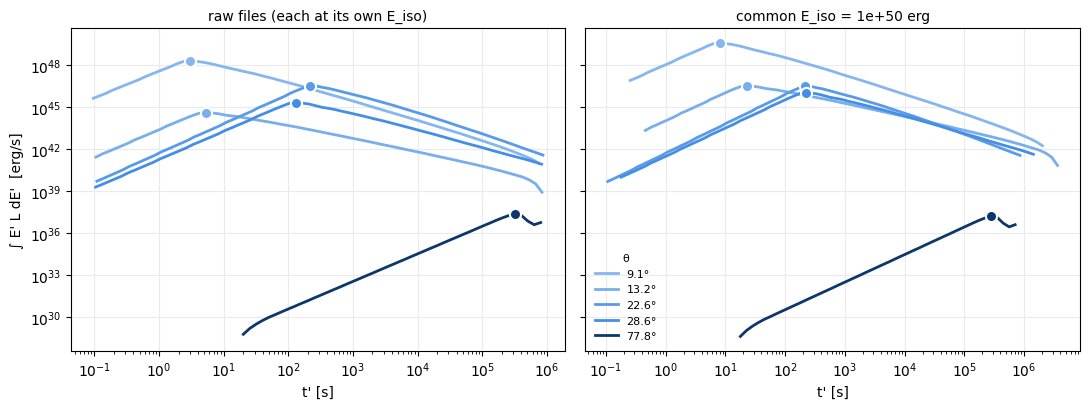

In [6]:
from matplotlib.colors import LinearSegmentedColormap, Normalize

E_ISO_REF = 1e50  # erg -- the common E_iso every angle is expressed at
model_set_std = model_set.rescaled_to_eiso(E_ISO_REF)  # default (a, b) = (1, 1/3)

# Peak (t'_pk, L_pk) of the energy-integrated light curve int E' L dE', per angle, for the raw
# files and for three candidate (a, b) scalings -- and whether each is monotonic in theta.
scalings = {"raw": None, "(1, 0)": (1.0, 0.0), "(2/3, 1/3)": (2 / 3, 1 / 3), "(1, 1/3) default": (1.0, 1 / 3)}
peaks = {name: [] for name in scalings}
for theta in model_set.angles_deg:
    for name, ab in scalings.items():
        m = model_set.models[theta]
        if ab is not None:
            m = m.rescaled_to_eiso(E_ISO_REF, L_exponent=ab[0], t_exponent=ab[1])
        peaks[name].append(m.peak())

print(f"{'theta [deg]':>12}" + "".join(f"{name:>22}" for name in scalings))
print(f"{'':>12}" + "".join(f"{'t_pk [s]  log L_pk':>22}" for _ in scalings))
for j, theta in enumerate(model_set.angles_deg):
    print(f"{theta:12.3f}" + "".join(f"{p[j][0]:12.3g}{np.log10(p[j][1]):10.2f}" for p in peaks.values()))
print(f"{'monotonic?':>12}" + "".join(
    f"{'t ' + ('yes' if np.all(np.diff([q[0] for q in p]) > 0) else 'NO'):>12}"
    f"{'L ' + ('yes' if np.all(np.diff([q[1] for q in p]) < 0) else 'NO'):>10}"
    for p in peaks.values()))

# Energy-integrated light curves, raw vs on the common E_iso; the dot marks each peak.
# theta is an ordered magnitude -> one blue ramp, light (small theta) to dark (large theta).
theta_cmap = LinearSegmentedColormap.from_list("theta", ["#86b6ef", "#3987e5", "#184f95", "#0d366b"])
theta_norm = Normalize(model_set.angles_deg[0], model_set.angles_deg[-1])
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, ms, title in [(axes[0], model_set, "raw files (each at its own E_iso)"),
                      (axes[1], model_set_std, f"common E_iso = {E_ISO_REF:.0e} erg")]:
    for theta in ms.angles_deg:
        m, color = ms.models[theta], theta_cmap(theta_norm(theta))
        ax.loglog(m.time, m.light_curve(), color=color, lw=2, label=f"{theta:.1f}°")
        ax.plot(*m.peak(), "o", ms=8, color=color, mec="white", mew=1.5)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("t' [s]")
    ax.grid(True, which="major", color="0.92", lw=0.8)
axes[0].set_ylabel("∫ E' L dE'  [erg/s]")
axes[1].legend(title="θ", fontsize=8, title_fontsize=8, frameon=False)
fig.tight_layout()
plt.show()

### Peak-aligned interpolation (Option C)

On the common `E_iso`, the 13.2° and 22.6° files peak about one decade apart
in `t'` (23 s vs 215 s). Interpolating `log L` at fixed `t'` blends the two
peaks into the double-peaked light curve the notes warn about.
`get_model(θ, method="interp")` instead interpolates at fixed **phase**
`x = log t' − log t'_pk`:

$$\log L(E', x;\theta) = (1-w)\,\log L_a(E', x) + w\,\log L_b(E', x),\qquad
\log t'_{\rm pk}(\theta) = (1-w)\log t'_{{\rm pk},a} + w\log t'_{{\rm pk},b},\qquad
w = \frac{\theta-\theta_a}{\theta_b-\theta_a}.$$

Both inputs peak at `x = 0`, so the result also peaks there, once, at the
interpolated time. The peak luminosity, and the rise/decay slope
`d log L / d log t'` at every phase, are all the same linear-in-θ blend of the
two brackets.

Two details:

- **One time shift per file is enough.** Every catO5 peak is achromatic (the same time bin at every energy).
- **Each input is first cut to its single-peaked part.** The 77.8° file re-brightens at its very last time node. Extrapolating that rise as a power law would leak into the whole 28.6°–77.8° range.

`align_peaks=False` gives back the plain fixed-`t'` version, for comparison.

In [7]:
theta_query = 18.0  # deg -- pick something strictly between two tabulated angles
rng = np.random.default_rng(0)

m_nearest      = model_set_std.get_model(theta_query, method="nearest")
m_stochastic   = model_set_std.get_model(theta_query, method="stochastic", rng=rng)
m_interp       = model_set_std.get_model(theta_query, method="interp")                     # peak-aligned
m_interp_fixed = model_set_std.get_model(theta_query, method="interp", align_peaks=False)  # plain, for comparison

print(f"theta_query = {theta_query} deg  (every model at E_iso = {E_ISO_REF:.0e} erg)")
print(f"  A. nearest    -> uses the theta={m_nearest.theta_deg} deg file as-is")
print(f"  B. stochastic -> this draw picked theta={m_stochastic.theta_deg} deg "
      "(repeat with different rng seeds: unbiased on average, not per draw)")
print(f"  C. interp     -> a virtual model at theta={m_interp.theta_deg} deg, "
      f"peak-aligned log-L interpolation between {m_interp.meta['bracket_deg']} deg")

theta_a, theta_b = m_interp.meta["bracket_deg"]
w = (theta_query - theta_a) / (theta_b - theta_a)
(t_a, L_a), (t_b, L_b) = model_set_std.models[theta_a].peak(), model_set_std.models[theta_b].peak()
print(f"\n  peak time: {t_a:.3g} s ({theta_a} deg) -> {m_interp.peak()[0]:.3g} s here "
      f"-> {t_b:.3g} s ({theta_b} deg);  log-interpolated: {t_a ** (1 - w) * t_b ** w:.3g} s")

theta_query = 18.0 deg  (every model at E_iso = 1e+50 erg)
  A. nearest    -> uses the theta=22.631 deg file as-is
  B. stochastic -> this draw picked theta=13.167 deg (repeat with different rng seeds: unbiased on average, not per draw)
  C. interp     -> a virtual model at theta=18.0 deg, peak-aligned log-L interpolation between (13.167, 22.631) deg

  peak time: 22.9 s (13.167 deg) -> 71.9 s here -> 215 s (22.631 deg);  log-interpolated: 71.9 s


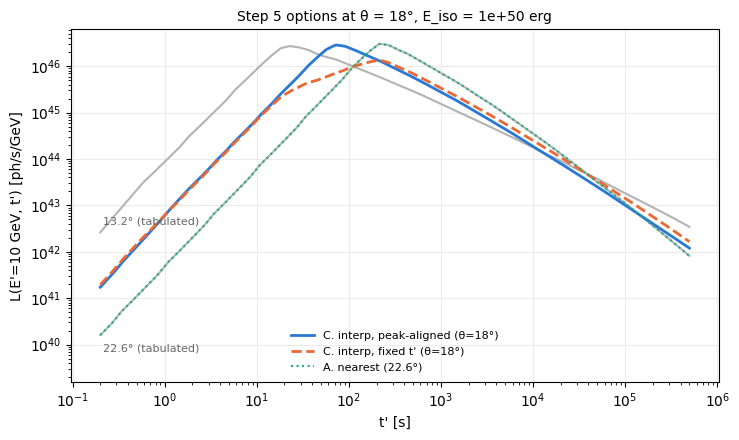

In [8]:
# Compare the options' light curves at a fixed rest-frame energy.
E_fixed = 10.0  # GeV, rest frame
t_grid = np.geomspace(0.2, 5e5, 400)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
for theta, dy in [(theta_a, 6), (theta_b, -12)]:
    L_theta = model_set_std.models[theta].at(E_fixed, t_grid)[0]
    ax.loglog(t_grid, L_theta, color="0.7", lw=1.5)
    ax.annotate(f"{theta:.1f}° (tabulated)", xy=(t_grid[0], L_theta[0]), xytext=(2, dy),
                textcoords="offset points", fontsize=8, color="0.4")
ax.loglog(t_grid, m_interp.at(E_fixed, t_grid)[0], color="#2a78d6", lw=2,
          label=f"C. interp, peak-aligned (θ={theta_query:g}°)")
ax.loglog(t_grid, m_interp_fixed.at(E_fixed, t_grid)[0], color="#eb6834", lw=2, ls="--",
          label=f"C. interp, fixed t' (θ={theta_query:g}°)")
ax.loglog(t_grid, m_nearest.at(E_fixed, t_grid)[0], color="#1baf7a", lw=1.5, ls=":",
          label=f"A. nearest ({m_nearest.theta_deg:.1f}°)")
ax.set_xlabel("t' [s]"); ax.set_ylabel(f"L(E'={E_fixed:g} GeV, t') [ph/s/GeV]")
ax.set_ylim(bottom=ax.get_ylim()[0] / 5)  # room for the lower label
ax.set_title(f"Step 5 options at θ = {theta_query:g}°, E_iso = {E_ISO_REF:.0e} erg", fontsize=10)
ax.grid(True, which="major", color="0.92", lw=0.8)
ax.legend(fontsize=8, frameon=False, loc="lower center")
fig.tight_layout()
plt.show()

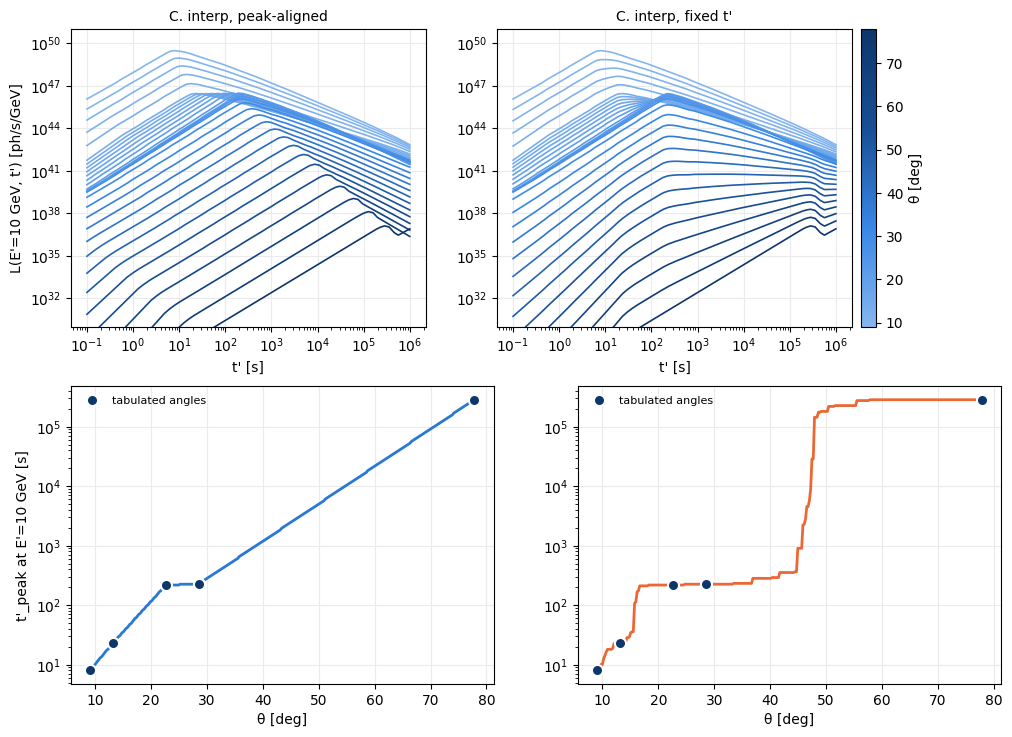

In [9]:
# The whole tabulated theta range: light curves at E_fixed (top) and the peak trajectory (bottom),
# peak-aligned vs fixed-t'. Log-spaced thetas put more curves in the narrow low-theta brackets;
# t' stops at 1e6 s, where the files do (beyond it the raw 77.8 deg file's last-node rise is extrapolated).
theta_sweep = np.geomspace(model_set_std.angles_deg[0], model_set_std.angles_deg[-1], 30)
theta_fine = np.linspace(model_set_std.angles_deg[0], model_set_std.angles_deg[-1], 300)
t_grid = np.geomspace(0.1, 1e6, 500)

fig, axes = plt.subplots(2, 2, figsize=(12, 8.5))
for col, (align, name) in enumerate([(True, "peak-aligned"), (False, "fixed t'")]):
    ax = axes[0, col]
    for theta in theta_sweep:
        m = model_set_std.get_model(theta, method="interp", align_peaks=align)
        ax.loglog(t_grid, m.at(E_fixed, t_grid)[0], color=theta_cmap(theta_norm(theta)), lw=1.2)
    ax.set_title(f"C. interp, {name}", fontsize=10)
    ax.set_xlabel("t' [s]")
    ax.set_ylim(1e30, None)
    ax.grid(True, which="major", color="0.92", lw=0.8)

    # Peak time of the light curve at E_fixed vs theta (the global maximum, for fixed-t').
    t_pk = [t_grid[np.argmax(model_set_std.get_model(th, method="interp", align_peaks=align)
                             .at(E_fixed, t_grid)[0])] for th in theta_fine]
    ax = axes[1, col]
    ax.semilogy(theta_fine, t_pk, color="#2a78d6" if align else "#eb6834", lw=2)
    ax.semilogy(model_set_std.angles_deg, [model_set_std.models[th].peak()[0] for th in model_set_std.angles_deg],
                "o", ms=8, color="#0d366b", mec="white", mew=1.5, label="tabulated angles")
    ax.set_xlabel("θ [deg]")
    ax.grid(True, which="major", color="0.92", lw=0.8)
    ax.legend(fontsize=8, frameon=False, loc="upper left")
axes[0, 1].sharey(axes[0, 0])
axes[1, 1].sharey(axes[1, 0])
axes[0, 0].set_ylabel(f"L(E'={E_fixed:g} GeV, t') [ph/s/GeV]")
axes[1, 0].set_ylabel(f"t'_peak at E'={E_fixed:g} GeV [s]")
fig.colorbar(plt.cm.ScalarMappable(norm=theta_norm, cmap=theta_cmap), ax=axes[0, :], label="θ [deg]", pad=0.01)
plt.show()

In [10]:
# CROSSCHECK 3 -- the peak-aligned interpolation is single-peaked at every theta and energy
# (extrapolated tails included), and it commutes with the common-E_iso rescaling.
def n_peaks(logL):
    d = np.diff(logL)
    d = d[np.abs(d) > 1e-12]  # ignore float-exact plateaus
    return int(np.sum((d[:-1] > 0) & (d[1:] < 0)))

E_check = np.array([1.5, 10.0, 100.0, 1000.0])  # GeV, rest frame
t_check = np.geomspace(1e-2, 1e8, 3000)
theta_check = np.linspace(model_set_std.angles_deg[0], model_set_std.angles_deg[-1], 400)[1:-1]
for align, name in [(True, "peak-aligned"), (False, "fixed t'")]:
    n_multi = np.zeros(E_check.size, int)
    for theta in theta_check:
        logL = np.log10(model_set_std.get_model(theta, method="interp", align_peaks=align).at(E_check, t_check))
        n_multi += [n_peaks(row) > 1 for row in logL]
    print(f"{name:>13}: thetas (of {theta_check.size}) with >1 peak at E' = {E_check} GeV: {n_multi}")

E_q, t_q = np.geomspace(2, 5e3, 30), np.geomspace(1, 1e6, 40)
err = max(np.max(np.abs(np.log10(
    model_set_std.get_model(theta, method="interp").at(E_q, t_q)
    / model_set.get_model(theta, method="interp").rescaled_to_eiso(E_ISO_REF).at(E_q, t_q))))
    for theta in theta_check[::20])
print(f"\nrescale-then-interpolate vs interpolate-then-rescale: max |d log10 L| = {err:.1e}")

 peak-aligned: thetas (of 398) with >1 peak at E' = [   1.5   10.   100.  1000. ] GeV: [0 0 0 0]
     fixed t': thetas (of 398) with >1 peak at E' = [   1.5   10.   100.  1000. ] GeV: [58 63 68 64]

rescale-then-interpolate vs interpolate-then-rescale: max |d log10 L| = 1.7e-13


### Saving the standardized cache

One `.npz` per angle, written to
[`data/models/grb_afterglow_inaf/standardized/`](../data/models/grb_afterglow_inaf/standardized).
This is the only thing `sim_3d` (or any later notebook) needs to touch — it
never parses a FITS file directly. The cache keeps each file at its own
`E_iso` (lossless). The common-`E_iso` rescaling is one call after loading,
so `E_ISO_REF` can change without regenerating anything.

In [11]:
model_set.save(paths.GRB_MODEL_STANDARDIZED_DIR)

reloaded = grb_model.GRBModelSet.load(paths.GRB_MODEL_STANDARDIZED_DIR)
assert np.allclose(reloaded.angles_deg, model_set.angles_deg)
print(f"Standardized cache written: {len(reloaded.models)} angle(s) in "
      f"{paths.GRB_MODEL_STANDARDIZED_DIR}")
for f in sorted(paths.GRB_MODEL_STANDARDIZED_DIR.glob('*.npz')):
    print(" ", f.name)


Standardized cache written: 5 angle(s) in /home/jjimenezq/projects/gw-gamma-global-uls/data/models/grb_afterglow_inaf/standardized
  theta_009.075deg.npz
  theta_013.167deg.npz
  theta_022.631deg.npz
  theta_028.554deg.npz
  theta_077.841deg.npz


## Part 2 — Options 2 & 3: analytic models (validation cases)

Not read from a file: Option 2 is any rest-frame `f(E') x g(t')` you define in
code (K-correction is analytic, Step 2 is skipped entirely), and Option 3 is
its Γ=2, constant-in-time special case, used as the closed-form validation
anchor in the guidelines' checklist. Both are cheap to build on demand, so
`sim_3d` can call `GRBModel.from_analytic` / `.constant_power_law` directly —
there is nothing to standardize/cache for these two.

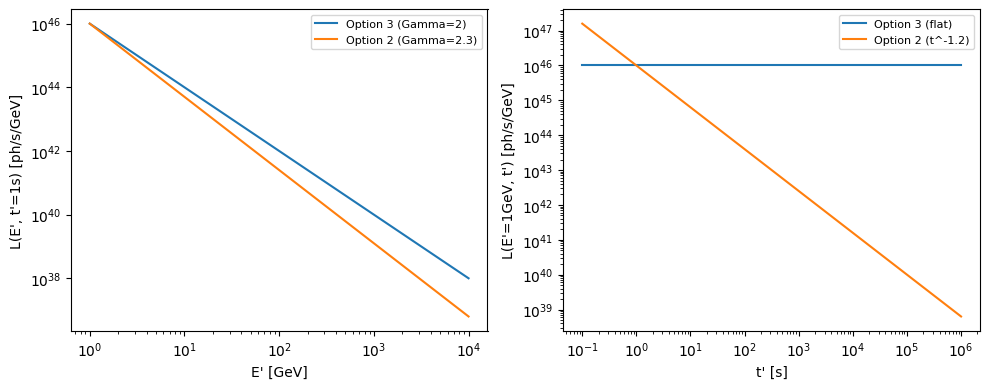

In [12]:
E_grid = np.geomspace(1, 1e4, 41)   # GeV, matches the INAF grid so the three options are comparable
t_grid = np.geomspace(0.1, 1e6, 70)  # s

# Option 3: Gamma=2 power law, constant in time -- the closed-form test case.
model_opt3 = grb_model.GRBModel.constant_power_law(E_grid, t_grid, index=2.0, L0=1e46, E_ref=1.0)

# Option 2: e.g. a steeper spectrum with a fading light curve (alpha=-1.2, a typical afterglow decay).
model_opt2 = grb_model.GRBModel.from_analytic(
    spectral_fn=lambda E: E ** -2.3,
    energy_rest=E_grid, time_rest=t_grid,
    temporal_fn=lambda t: (t / 1.0) ** -1.2,
    L0=1e46, E_ref=1.0,
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].loglog(E_grid, model_opt3.at(E_grid, 1.0)[:, 0], label="Option 3 (Gamma=2)")
axes[0].loglog(E_grid, model_opt2.at(E_grid, 1.0)[:, 0], label="Option 2 (Gamma=2.3)")
axes[0].set_xlabel("E' [GeV]"); axes[0].set_ylabel("L(E', t'=1s) [ph/s/GeV]"); axes[0].legend(fontsize=8)
axes[1].loglog(t_grid, model_opt3.at(1.0, t_grid)[0], label="Option 3 (flat)")
axes[1].loglog(t_grid, model_opt2.at(1.0, t_grid)[0], label="Option 2 (t^-1.2)")
axes[1].set_xlabel("t' [s]"); axes[1].set_ylabel("L(E'=1GeV, t') [ph/s/GeV]"); axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()


## How `sim_3d` consumes this

```python
from gwuls import grb_model, paths

model_set = grb_model.GRBModelSet.load(paths.GRB_MODEL_STANDARDIZED_DIR)  # Option 1, each file at its own E_iso
model_set = model_set.rescaled_to_eiso(1e50)                               # every angle on one common E_iso

# per iteration i, after theta_i has been drawn (Step 4.3):
L_i = model_set.evaluate(theta_i, E_prime_grid, t_prime_grid, method="interp")  # peak-aligned
# (or method="stochastic", rng=rng; to also draw E_iso per iteration:
#  model_set.get_model(theta_i, method="interp").rescaled_to_eiso(E_iso_i).at(E_prime_grid, t_prime_grid))

# or, for the analytic validation cases (Options 2/3), built on the spot:
model_opt3 = grb_model.GRBModel.constant_power_law(E_grid, t_grid, index=2.0, L0=L0)
```

`GRBModel.to_observer(D_L_i, z_i, ...)` then implements Step 7 for whichever
model was selected.